# BKG Studies

In [7]:
# python
import sys
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
# from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
from hist import Hist
import numpy as np
# from sidm.definitions.hists import constants


In [8]:
# Ouput files generated
# 01: test sample hist to assure the notebook runs
# 02: add lostHits >= 1 cuts to electrons
# 03: after updating main branch
# 04: All files for 1 2mu, 4mu and TTJets
# 05: 15 files for:
    # "2Mu2E_100GeV_5p0GeV_0p4mm", "2Mu2E_500GeV_5p0GeV_0p08mm"
    # "4Mu_100GeV_5p0GeV_0p4mm", "4Mu_500GeV_5p0GeV_0p08mm",
    # "DYJetsToMuMu_M10to50","DYJetsToMuMu_M50", "TTJets", "QCD_Pt50To80", "QCD_Pt80To120",

In [9]:
# my settings
numfiles = 15
vr = "05"

sig_2mu = [
    "2Mu2E_100GeV_5p0GeV_0p4mm",
    # "2Mu2E_150GeV_5p0GeV_0p27mm",
    # "2Mu2E_200GeV_5p0GeV_0p2mm",
    "2Mu2E_500GeV_5p0GeV_0p08mm",
    # "2Mu2E_500GeV_5p0GeV_80p0mm",
    # "2Mu2E_800GeV_5p0GeV_0p05mm",
    # "2Mu2E_1000GeV_5p0GeV_0p04mm",
]
sig_4mu = [
    "4Mu_100GeV_5p0GeV_0p4mm",
    # "4Mu_150GeV_5p0GeV_0p27mm",
    # "4Mu_200GeV_5p0GeV_0p2mm",
    "4Mu_500GeV_5p0GeV_0p08mm",
    # "4Mu_500GeV_5p0GeV_80p0mm",
    # "4Mu_800GeV_5p0GeV_0p05mm",
    # "4Mu_1000GeV_5p0GeV_0p04mm",
]
bkg = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
    "TTJets",
    # "QCD_Pt15To20",
    # "QCD_Pt20To30",
    # "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    # "QCD_Pt120To170",
    # "QCD_Pt170To300",
    # "QCD_Pt300To470",
    # "QCD_Pt470To600",
    # "QCD_Pt600To800",
    # "QCD_Pt800To1000",
    # "QCD_Pt1000",       
]

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study", "bkg_study_iso",]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]

allsamples = sig_2mu + sig_4mu + bkg
print(allsamples)

['2Mu2E_100GeV_5p0GeV_0p4mm', '2Mu2E_500GeV_5p0GeV_0p08mm', '4Mu_100GeV_5p0GeV_0p4mm', '4Mu_500GeV_5p0GeV_0p08mm', 'DYJetsToMuMu_M10to50', 'DYJetsToMuMu_M50', 'TTJets', 'QCD_Pt50To80', 'QCD_Pt80To120']


In [5]:
#stop here

In [4]:
# processor for 2mu2e

fileset_sig_2mu = utilities.make_fileset(sig_2mu,  "llpNanoAOD_v2", max_files = numfiles, location_cfg = "signal_2mu2e_v10.yaml")

runner = processor.Runner(
    executor=processor.FuturesExecutor(),
    # executor=processor.IterativeExecutor(),
    # executor=processor.DaskExecutor(client=client),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    # schema=NanoAODSchema,
    # maxchunks=1,
    skipbadfiles=True,
)

#hist collection
p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"], unweighted_hist=True,
)

out_sig = runner.run(fileset_sig_2mu, treename="Events", processor_instance=p)
out_sig = out_sig["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


#--------------------------------------------------------------------------
#                         FastJet release 3.4.3
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


2Mu2E_500GeV_5p0GeV_0p08mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_100GeV_5p0GeV_0p4mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [5]:
# processor for signal

fileset_sig_4mu = utilities.make_fileset(sig_4mu,  "llpNanoAOD_v2", max_files = numfiles, location_cfg = "signal_4mu_v10.yaml")

runner = processor.Runner(
    executor=processor.FuturesExecutor(),
    # executor=processor.IterativeExecutor(),
    # executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    # maxchunks=1,
    skipbadfiles=True,
)

#hist collection
p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"], unweighted_hist=True,
)

out_sig4 = runner.run(fileset_sig_4mu, treename="Events", processor_instance=p)
out_sig4 = out_sig4["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


#--------------------------------------------------------------------------
#                         FastJet release 3.4.3
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


4Mu_500GeV_5p0GeV_0p08mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_100GeV_5p0GeV_0p4mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [6]:
# processor for BKG ...

fileset_bkg    = utilities.make_fileset(bkg, "llpNanoAOD_v2", max_files = numfiles, location_cfg = "backgrounds.yaml",)

runner = processor.Runner(
    executor=processor.FuturesExecutor(),
    # executor=processor.IterativeExecutor(),
    # executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    # maxchunks=1,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"], unweighted_hist=True,
)

out_bkg = runner.run(fileset_bkg, treename="Events", processor_instance=p)
out_bkg = out_bkg["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


#--------------------------------------------------------------------------
#                         FastJet release 3.4.3
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


QCD_Pt80To120 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt50To80 is simulation. Scaling histograms or cutflows according to lumi*xs.
TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.
DYJetsToMuMu_M50 is simulation. Scaling histograms or cutflows according to lumi*xs.
DYJetsToMuMu_M10to50 is simulation. Scaling histograms or cutflows according to lumi*xs.


In [6]:
# adding and saving
out_all = out_sig | out_sig4 | out_bkg 
coffea.util.save(out_all, "outputs/bkg_" + vr + ".coffea")
## Tests:
print(out_all.keys())

NameError: name 'out_sig' is not defined

dict_keys(['2Mu2E_500GeV_5p0GeV_0p08mm', '2Mu2E_100GeV_5p0GeV_0p4mm', '4Mu_500GeV_5p0GeV_0p08mm', '4Mu_100GeV_5p0GeV_0p4mm', 'QCD_Pt80To120', 'QCD_Pt50To80', 'TTJets', 'DYJetsToMuMu_M50', 'DYJetsToMuMu_M10to50'])


In [ ]:
# Start plotting

In [3]:
# sig_leg = [s.split("_")[1] + "  " + s.split("_")[2] + "  " + s.split("_")[3] for s in sig_2mu]
figw, figh = 12, 10

# cols = ["b", "r", "g", "c", "k", "y"]
# labels = ["0.15", "0.17", "0.19", "0.21", "0.23", "0.25"]

In [10]:
# loading file
output = coffea.util.load("outputs/bkg_" + vr + ".coffea")
out = output

2Mu2E_100GeV_5p0GeV_0p4mm
2Mu2E_500GeV_5p0GeV_0p08mm
4Mu_100GeV_5p0GeV_0p4mm
4Mu_500GeV_5p0GeV_0p08mm
DYJetsToMuMu_M10to50
DYJetsToMuMu_M50
TTJets
QCD_Pt50To80
QCD_Pt80To120


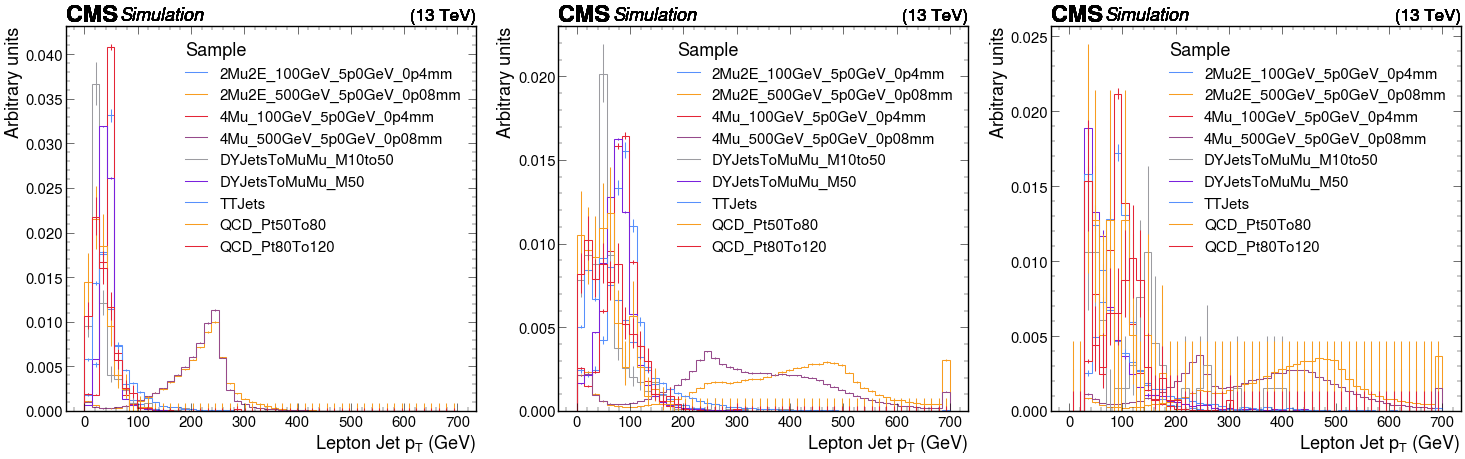

In [11]:
#lj_pt
npl = 3
plt.subplots(1, npl, figsize=(npl*figw, figh))

plt.subplot(1, npl, 1)
for sss in allsamples:
    # print(sss)
    utilities.plot(out[sss]["hists"]["lj_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in allsamples:
    utilities.plot(out[sss]["hists"]["lj_pt"][ch2, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 3)
for sss in allsamples:
    utilities.plot(out[sss]["hists"]["lj_pt"][ch3, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

In [ ]:
# LJ quantities

# "lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR""lj_lj_absdeta"
# , "lj_lj_absdR", "lj_lj_invmass"]
hists_to_plot = ["lj_n","lj0_pt", "lj1_pt"]

for hst in hists_to_plot:
    npl = 3
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    
    plt.subplot(1, npl, 1)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch1, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 2)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch2, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 3)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch3, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")

In [ ]:
# LJ-LJ quantities

hists_to_plot = ["lj_lj_invmass", "lj_lj_absdR", "lj_lj_absdphi", "lj_lj_absdeta"]

for hst in hists_to_plot:
    npl = 3
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    
    plt.subplot(1, npl, 1)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch1, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 2)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch2, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 3)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch3, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")